First 5 rows of dataset:
         Date    Open    High     Low   Close   Volume  Daily_Return_Pct  \
0  1980-01-02  0.1937  0.1944  0.1895  0.1895  3451200               NaN   
1  1980-01-03  0.1895  0.1951  0.1881  0.1944  3960000            2.5858   
2  1980-01-04  0.1944  0.1965  0.1937  0.1965  1694400            1.0802   
3  1980-01-07  0.1965  0.1972  0.1951  0.1958  4396800           -0.3562   
4  1980-01-08  0.1958  0.1979  0.1958  0.1972  3244800            0.7150   

   Daily_Range  MA_20  MA_50  ...  BB_Upper  BB_Lower  BB_Width  RSI_14  \
0       0.0049    NaN    NaN  ...       NaN       NaN       NaN     NaN   
1       0.0070    NaN    NaN  ...       NaN       NaN       NaN     NaN   
2       0.0028    NaN    NaN  ...       NaN       NaN       NaN     NaN   
3       0.0021    NaN    NaN  ...       NaN       NaN       NaN     NaN   
4       0.0021    NaN    NaN  ...       NaN       NaN       NaN     NaN   

   Volume_MA_20  Cumulative_Return_Pct  Year  Month  Quarter  Day_o

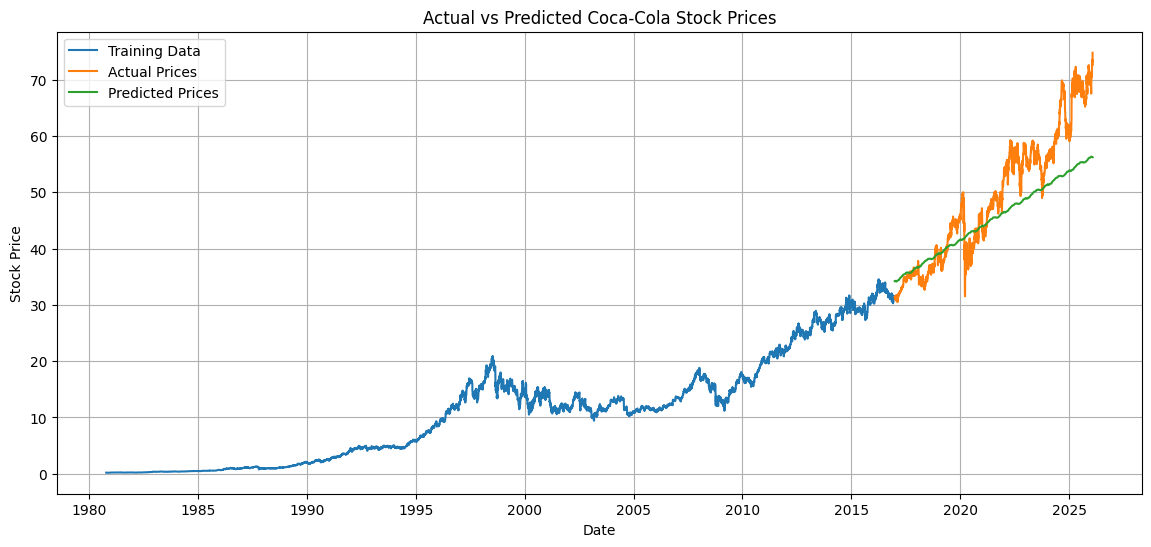


Future Predictions:
             ds       yhat  yhat_lower  yhat_upper
9492 2017-12-24  36.605195   35.282662   38.009125
9493 2017-12-25  36.609673   35.222524   38.025881
9494 2017-12-26  36.626608   35.198747   37.975305
9495 2017-12-27  36.645026   35.269880   38.109981
9496 2017-12-28  36.658341   35.266361   38.042877


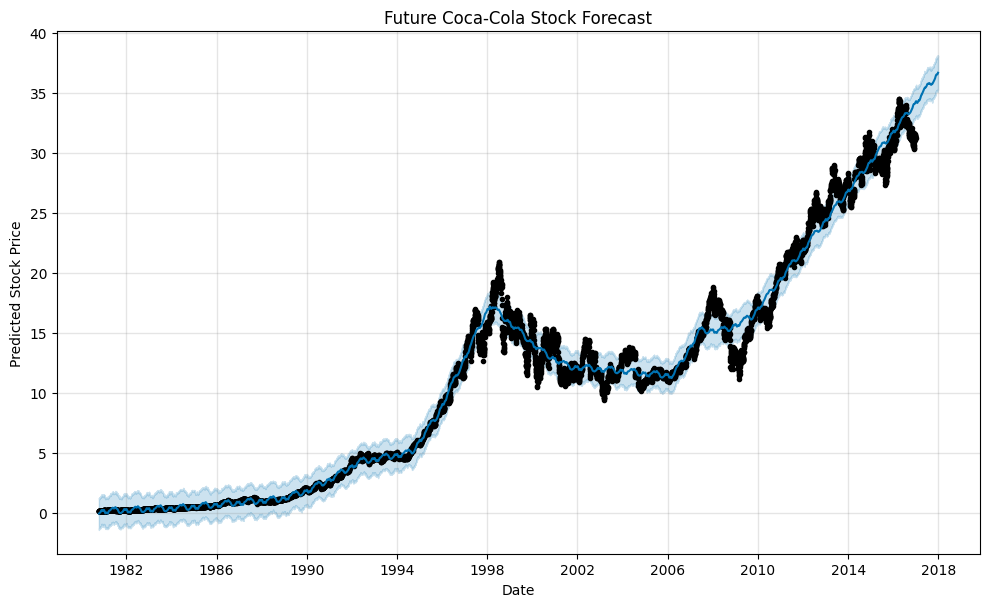

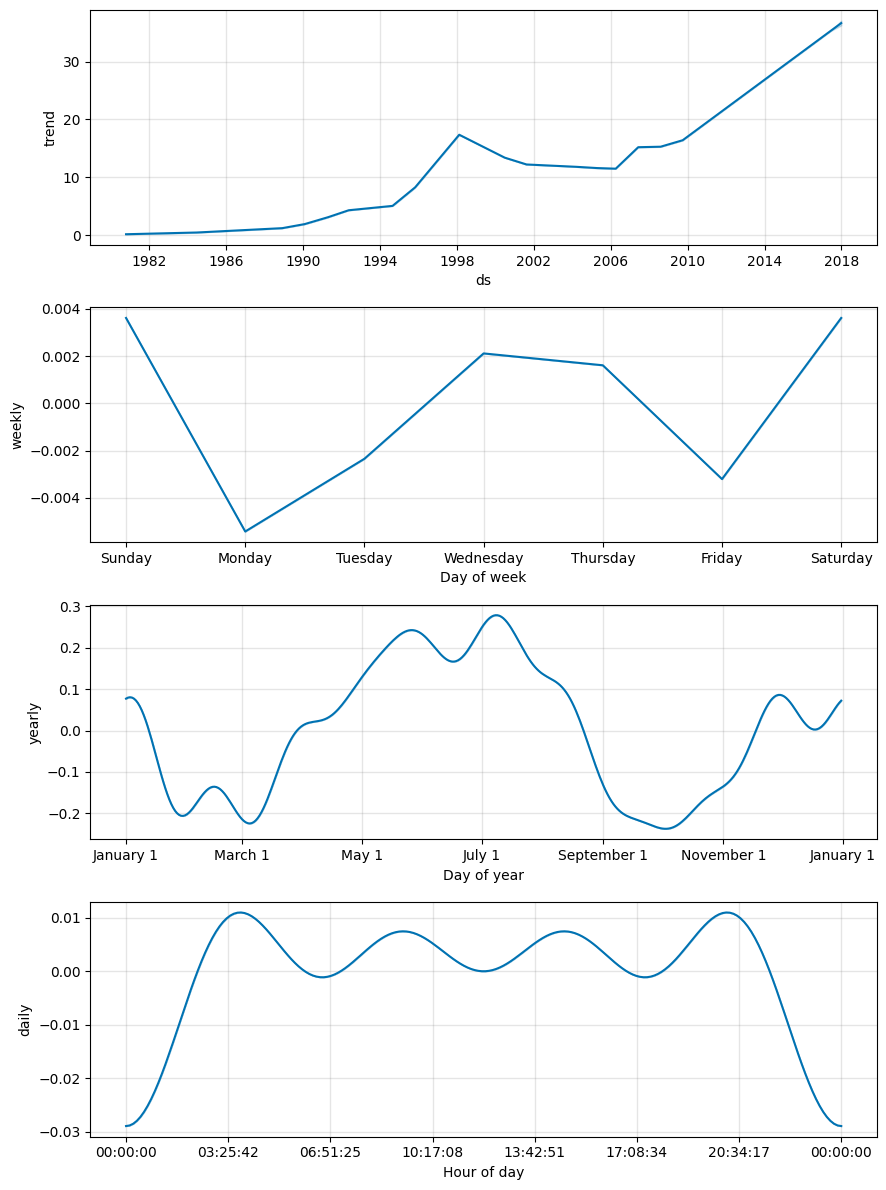

In [2]:
# Predictive Modeling using Coca-Cola Stock Dataset
# Forecast Future Trends using Time Series (Facebook Prophet)

# Install required libraries (run once if needed)
# pip install pandas matplotlib scikit-learn prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet

# -------------------------------
# STEP 1: Load Dataset
# -------------------------------

# Replace with your CSV file name
df = pd.read_csv("/content/KO_CocaCola_Stock_Prices_1980_2026.csv")

print("First 5 rows of dataset:")
print(df.head())

# -------------------------------
# STEP 2: Data Preprocessing
# -------------------------------

# Check column names
print("\nColumns in dataset:")
print(df.columns)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Remove missing values
df = df.dropna()

# Keep only Date and Close Price
# Change 'Close' if your dataset uses another column name
df = df[['Date', 'Close']]

# Rename columns for Prophet
df.columns = ['ds', 'y']

print("\nCleaned Dataset:")
print(df.head())

# -------------------------------
# STEP 3: Train-Test Split
# -------------------------------

# 80% training, 20% testing
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

print("\nTraining Data Size:", len(train))
print("Testing Data Size:", len(test))

# -------------------------------
# STEP 4: Build Predictive Model
# -------------------------------

# Create Prophet model
model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True
)

# Train model
model.fit(train)

# -------------------------------
# STEP 5: Predict on Test Data
# -------------------------------

future_test = test[['ds']]

forecast_test = model.predict(future_test)

# -------------------------------
# STEP 6: Model Evaluation
# -------------------------------

actual = test['y'].values
predicted = forecast_test['yhat'].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

print("\nModel Evaluation")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

# -------------------------------
# STEP 7: Visualize Predictions
# -------------------------------

plt.figure(figsize=(14, 6))

plt.plot(train['ds'], train['y'],
         label='Training Data')

plt.plot(test['ds'], test['y'],
         label='Actual Prices')

plt.plot(test['ds'], predicted,
         label='Predicted Prices')

plt.title("Actual vs Predicted Coca-Cola Stock Prices")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# STEP 8: Forecast Future Trends
# -------------------------------

# Predict next 365 days
future = model.make_future_dataframe(periods=365)

forecast = model.predict(future)

# Show forecast
print("\nFuture Predictions:")
print(forecast[['ds', 'yhat',
                'yhat_lower',
                'yhat_upper']].tail())

# -------------------------------
# STEP 9: Forecast Visualization
# -------------------------------

model.plot(forecast)
plt.title("Future Coca-Cola Stock Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Stock Price")
plt.grid(True)
plt.show()

# -------------------------------
# STEP 10: Trend Components
# -------------------------------

model.plot_components(forecast)
plt.show()